<a href="https://colab.research.google.com/github/abhijeetmahamuni1/EV-Market-Analysis/blob/main/EV_(Electric_Vehicle)_Market_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EV (Electric Vehicle) Market Analysis

1 How are EV registrations changing over time?
2 Which EV manufacturer has the highest market share?
3 Which EV model is most popular?
4 Which state has the highest EV adoption?
5 Which vehicle category is growing fastest?
6 What is the average EV price by manufacturer?
7 How does battery range vary by manufacturer?
8 Is vehicle price related to battery range?
9 Which states show the strongest EV growth?
10 What factors appear to influence EV adoption?

And importantly: I won't give you a clean dataset. You'll have to inspect → clean → transform → analyze → visualize → explain, just like a real analyst.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/drive/MyDrive/practice_data_set/EV_Market_Analysis_Unclean_Dataset.csv")

In [4]:
df.head()

,Record_ID,Registration_Date,Manufacturer,Model,Vehicle_Category,City,State,Price_INR,Battery_Range_KM,Units_Sold,Charging_Type,Area_Type
0,EV100000,2024-10-08,Tata,Punch EV,Electric Scooter,Delhi,Tamil Nadu,200075,91.0,15.0,Home,Rural
1,EV100001,2025-08-27,Tesla,Model 3,Electric Scooter,Ahmedabad,Maharashtra,97011,74.0,21.0,Home,Urban
2,EV100002,2024-07-22,Tata,Punch EV,Electric Scooter,Kolkata,Uttar Pradesh,250000,133.0,28.0,Fast Charging,Rural
3,EV100003,2025-12-15,Tata,Nexon EV,Electric Car,Ahmedabad,Telangana,2386927,297.0,11.0,Home,Semi-Urban
4,EV100004,2025-01-02,tata,S1 Pro,Electric Car,Chennai,West Bengal,3456598,291.0,3.0,Home,Rural


In [5]:
df.shape

(1225, 12)

In [6]:
df.columns

Index(['Record_ID', 'Registration_Date', 'Manufacturer', 'Model',
       'Vehicle_Category', 'City', 'State', 'Price_INR', 'Battery_Range_KM',
       'Units_Sold', 'Charging_Type', 'Area_Type'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1225 entries, 0 to 1224
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Record_ID          1225 non-null   object 
 1   Registration_Date  1225 non-null   object 
 2   Manufacturer       1225 non-null   object 
 3   Model              1225 non-null   object 
 4   Vehicle_Category   1225 non-null   object 
 5   City               1225 non-null   object 
 6   State              1207 non-null   object 
 7   Price_INR          1207 non-null   object 
 8   Battery_Range_KM   1197 non-null   float64
 9   Units_Sold         1220 non-null   float64
 10  Charging_Type      1225 non-null   object 
 11  Area_Type          1225 non-null   object 
dtypes: float64(2), object(10)
memory usage: 115.0+ KB


In [8]:
df.describe()

,Battery_Range_KM,Units_Sold
count,1197.000000,1220.000000
mean,254.077694,25.085246
std,147.911966,75.076057
min,70.000000,-5.000000
25%,141.000000,10.000000
50%,203.000000,17.000000
75%,361.000000,26.000000
max,599.000000,999.000000


In [9]:
df.isnull().sum()

,0
Record_ID,0
Registration_Date,0
Manufacturer,0
Model,0
Vehicle_Category,0
City,0
State,18
Price_INR,18
Battery_Range_KM,28
Units_Sold,5


In [10]:
df.dtypes

,0
Record_ID,object
Registration_Date,object
Manufacturer,object
Model,object
Vehicle_Category,object
City,object
State,object
Price_INR,object
Battery_Range_KM,float64
Units_Sold,float64


In [11]:
df.duplicated().sum()

np.int64(25)

In [12]:
df.nunique()

,0
Record_ID,1200
Registration_Date,707
Manufacturer,13
Model,22
Vehicle_Category,3
City,17
State,10
Price_INR,1023
Battery_Range_KM,422
Units_Sold,71


In [13]:
df[df.duplicated()]

,Record_ID,Registration_Date,Manufacturer,Model,Vehicle_Category,City,State,Price_INR,Battery_Range_KM,Units_Sold,Charging_Type,Area_Type
1200,EV100459,2026-01-24,Ola,S1 X,Electric Bike,Mumbai,West Bengal,116794,200.0,35.0,Public,Urban
1201,EV100457,2025-11-02,BYD,Seal,Electric Car,Kolkata,Gujarat,3215480,259.0,10.0,Public,Urban
1202,EV101022,2026-02-19,Tesla,Model Y,Electric Car,Ahmedabad,Uttar Pradesh,3303451,214.0,2.0,Public,Rural
1203,EV100141,2024-03-03,Kia,Carens EV,Electric Car,Ahmedabad,Gujarat,4008866,260.0,31.0,Home,Semi-Urban
1204,EV100668,2026-08-29,Tata,Nexon EV,Electric Car,Jaipur,Karnataka,2317756,545.0,47.0,Fast Charging,Urban
1205,EV101011,2026-08-30,Tesla,Model Y,Electric Car,Pune,Gujarat,2119537,205.0,11.0,Fast Charging,Rural
1206,EV100151,2025-04-09,Tesla,Model Y,Electric Bike,Kochi,West Bengal,350000,153.0,42.0,Public,Urban
1207,EV100830,2024-06-19,BYD,Seal,Electric Car,Jaipur,Karnataka,3092203,479.0,26.0,Fast Charging,Urban
1208,EV100750,2025-04-10,Ola,S1 Pro,Electric Bike,Kochi,Kerala,109337,174.0,28.0,Fast Charging,Semi-Urban
1209,EV100046,2024-11-08,Ather,Rizta,Electric Car,Delhi,Tamil Nadu,4036943,190.0,58.0,Home,Semi-Urban


In [14]:
df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.shape

(1200, 12)

In [17]:
df["Manufacturer"].value_counts()

,count
Manufacturer,
Hyundai,154
Ola,139
Mahindra,132
Tesla,130
Tata,130
Ather,124
MG,122
BYD,120
Kia,114


In [18]:
df["Manufacturer"] = df["Manufacturer"].str.strip()  # strip() remove extra spaces

In [19]:
df["Manufacturer"].value_counts()

,count
Manufacturer,
Hyundai,154
Ola,139
Mahindra,132
MG,131
Tata,130
Tesla,130
Ather,124
BYD,120
Kia,114


In [20]:
df["Manufacturer"] = df["Manufacturer"].str.title()

In [21]:
df["Manufacturer"].value_counts()

,count
Manufacturer,
Hyundai,154
Tata,146
Ola,139
Mahindra,132
Mg,131
Tesla,130
Ather,124
Byd,120
Kia,114


In [22]:
df["Manufacturer"] = df["Manufacturer"].replace({'Tata Motors':'Tata','TATA':'Tata','tata':'Tata','Mg':'MG','Byd':'BYD','Ola':'OLA','Kia':'KIA'})

In [23]:
df["Manufacturer"].value_counts()

,count
Manufacturer,
Tata,156
Hyundai,154
OLA,139
Mahindra,132
MG,131
Tesla,130
Ather,124
BYD,120
KIA,114


In [24]:
df.groupby("Manufacturer")["Units_Sold"].sum()

,Units_Sold
Manufacturer,
Ather,2467.0
BYD,4014.0
Hyundai,4179.0
KIA,2879.0
MG,2721.0
Mahindra,4385.0
OLA,2888.0
Tata,2904.0
Tesla,3559.0


In [25]:
df["City"].value_counts()

,count
City,
Lucknow,120
Kochi,110
Ahmedabad,104
Kolkata,102
Bengaluru,100
Jaipur,99
Pune,96
Chennai,95
Hyderabad,94


In [26]:
df["City"] = df["City"].str.strip()

In [27]:
df["City"].value_counts()

,count
City,
Lucknow,120
Kochi,110
Bengaluru,105
Ahmedabad,104
Kolkata,102
Pune,100
Jaipur,99
Chennai,95
Hyderabad,94


In [28]:
df.columns

Index(['Record_ID', 'Registration_Date', 'Manufacturer', 'Model',
       'Vehicle_Category', 'City', 'State', 'Price_INR', 'Battery_Range_KM',
       'Units_Sold', 'Charging_Type', 'Area_Type'],
      dtype='object')

In [29]:
df["City"] = df["City"].str.title()

In [30]:
df["City"].value_counts()

,count
City,
Lucknow,120
Kochi,110
Bengaluru,105
Pune,105
Ahmedabad,104
Kolkata,102
Jaipur,99
Chennai,95
Mumbai,94


In [31]:
df["State"].value_counts()

,count
State,
Delhi,141
West Bengal,128
Rajasthan,126
Maharashtra,125
Tamil Nadu,120
Telangana,117
Gujarat,110
Uttar Pradesh,110
Kerala,104


In [32]:
df["State"].value_counts(dropna=False)

,count
State,
Delhi,141
West Bengal,128
Rajasthan,126
Maharashtra,125
Tamil Nadu,120
Telangana,117
Uttar Pradesh,110
Gujarat,110
Kerala,104


In [33]:
df[df["State"].isna()][["City","State"]]

,City,State
84,Lucknow,NaN
89,Hyderabad,NaN
153,Chennai,NaN
178,Chennai,NaN
202,Lucknow,NaN
217,Bengaluru,NaN
246,Kochi,NaN
267,Delhi,NaN
314,Ahmedabad,NaN
390,Kochi,NaN


In [34]:
df.iloc[84]

,84
Record_ID,EV100084
Registration_Date,2024-11-09
Manufacturer,OLA
Model,S1 Pro
Vehicle_Category,Electric Car
City,Lucknow
State,NaN
Price_INR,1337942
Battery_Range_KM,335.0
Units_Sold,12.0


In [35]:
city_state_map = {
    'Lucknow': 'Uttar Pradesh',
    'Hyderabad': 'Telangana',
    'Chennai': 'Tamil Nadu',
    'Bengaluru': 'Karnataka',
    'Kochi': 'Kerala',
    'Delhi': 'Delhi',
    'Ahmedabad': 'Gujarat',
    'Mumbai': 'Maharashtra',
    'Kolkata': 'West Bengal',
    'Pune': 'Maharashtra',
    'Nagpur': 'Maharashtra',
    'Jaipur': 'Rajasthan'
}

In [36]:
df["State"] = df["State"].fillna(df["State"].map(city_state_map))

In [37]:
df["State"].isna().sum()

np.int64(18)

In [38]:
df.loc[df["State"].isna(),["City","State"]]

,City,State
84,Lucknow,NaN
89,Hyderabad,NaN
153,Chennai,NaN
178,Chennai,NaN
202,Lucknow,NaN
217,Bengaluru,NaN
246,Kochi,NaN
267,Delhi,NaN
314,Ahmedabad,NaN
390,Kochi,NaN


In [39]:
df["State"].map(city_state_map)

,State
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1195,NaN
1196,NaN
1197,NaN
1198,NaN


In [40]:
df[df["State"].isna()][["City","State"]]

,City,State
84,Lucknow,NaN
89,Hyderabad,NaN
153,Chennai,NaN
178,Chennai,NaN
202,Lucknow,NaN
217,Bengaluru,NaN
246,Kochi,NaN
267,Delhi,NaN
314,Ahmedabad,NaN
390,Kochi,NaN


In [41]:
df.loc[df["State"].isna(),"City"].value_counts()

,count
City,
Hyderabad,4
Kochi,3
Chennai,3
Lucknow,2
Ahmedabad,2
Bengaluru,1
Delhi,1
Mumbai,1
Kolkata,1


In [42]:
df["State"].isnull().sum()

np.int64(18)

In [43]:
city_state_map = {
    'Lucknow': 'Uttar Pradesh',
    'Hyderabad': 'Telangana',
    'Chennai': 'Tamil Nadu',
    'Bengaluru': 'Karnataka',
    'Kochi': 'Kerala',
    'Delhi': 'Delhi',
    'Ahmedabad': 'Gujarat',
    'Mumbai': 'Maharashtra',
    'Kolkata': 'West Bengal',
    'Pune': 'Maharashtra',
    'Nagpur': 'Maharashtra',
    'Jaipur': 'Rajasthan'
}

In [44]:
df["State"] = df["State"].fillna(df["State"].map(city_state_map))

In [45]:
df["State"].isna().sum()

np.int64(18)

In [46]:
print(df.loc[df['State'].isna(), 'City'].tolist())

['Lucknow', 'Hyderabad', 'Chennai', 'Chennai', 'Lucknow', 'Bengaluru', 'Kochi', 'Delhi', 'Ahmedabad', 'Kochi', 'Hyderabad', 'Chennai', 'Hyderabad', 'Kochi', 'Hyderabad', 'Mumbai', 'Kolkata', 'Ahmedabad']


In [47]:
mask = df['State'].isna()

df.loc[mask, 'State'] = df.loc[mask, 'City'].map(city_state_map)

In [48]:
df["State"].isna().sum()

np.int64(0)

In [49]:
df.isnull().sum()

,0
Record_ID,0
Registration_Date,0
Manufacturer,0
Model,0
Vehicle_Category,0
City,0
State,0
Price_INR,18
Battery_Range_KM,28
Units_Sold,5


In [50]:
df["Price_INR"].info()

<class 'pandas.core.series.Series'>
Index: 1200 entries, 0 to 1199
Series name: Price_INR
Non-Null Count  Dtype 
--------------  ----- 
1182 non-null   object
dtypes: object(1)
memory usage: 18.8+ KB


In [51]:
df["Price_INR"].head(20)

,Price_INR
0,200075
1,97011
2,250000
3,2386927
4,3456598
5,231036
6,106331
7,2335295
8,172199
9,167924


In [52]:
df["Price_INR"].unique()[:20]

array(['200075', '97011', '250000', '2386927', '3456598', '231036',
       '106331', '2335295', '172199', '167924', '2364659', '173033',
       '231671', '350000', '223069', '101604', '2519636', '1863867',
       '2285962', '207914'], dtype=object)

In [53]:
df["Price_INR"].head()

,Price_INR
0,200075
1,97011
2,250000
3,2386927
4,3456598


In [54]:
df[df["Price_INR"].isna()][["Model","Vehicle_Category","Price_INR"]]

,Model,Vehicle_Category,Price_INR
36,XEV 9e,Electric Car,NaN
78,Carens EV,Electric Car,NaN
104,Carens EV,Electric Bike,NaN
270,450X,Electric Scooter,NaN
299,S1 Pro,Electric Car,NaN
304,e6,Electric Scooter,NaN
393,Carens EV,Electric Scooter,NaN
408,Rizta,Electric Scooter,NaN
454,Seal,Electric Scooter,NaN
469,S1 X,Electric Scooter,NaN


In [55]:
df["Price_INR"].isnull().sum()

np.int64(18)

In [56]:
df["Price_INR"] = pd.to_numeric(df['Price_INR'], errors='coerce')

In [57]:
df["Price_INR"].info()

<class 'pandas.core.series.Series'>
Index: 1200 entries, 0 to 1199
Series name: Price_INR
Non-Null Count  Dtype  
--------------  -----  
1178 non-null   float64
dtypes: float64(1)
memory usage: 18.8 KB


In [58]:
df["Price_INR"].isna().sum()

np.int64(22)

In [59]:
df["Price_INR"].isnull().sum()

np.int64(22)

In [60]:
df["Price_INR"].head()

,Price_INR
0,200075.0
1,97011.0
2,250000.0
3,2386927.0
4,3456598.0


In [61]:
df[df["Price_INR"].isna()][["Model","Record_ID","Price_INR"]]

,Model,Record_ID,Price_INR
36,XEV 9e,EV100036,NaN
78,Carens EV,EV100078,NaN
104,Carens EV,EV100104,NaN
186,Punch EV,EV100186,NaN
246,Creta Electric,EV100246,NaN
270,450X,EV100270,NaN
299,S1 Pro,EV100299,NaN
304,e6,EV100304,NaN
393,Carens EV,EV100393,NaN
408,Rizta,EV100408,NaN


In [62]:
df.groupby("Model")["Price_INR"].agg(["count","mean","median"])

,count,mean,median
Model,,,
450X,53,1.483186e+06,274032.0
Atto 3,36,1.472770e+06,226299.5
BE 6,39,1.449028e+06,250000.0
Carens EV,58,1.278673e+06,250000.0
Comet EV,61,1.577649e+06,262451.0
Creta Electric,57,1.809140e+06,1238927.0
EV6,61,1.547001e+06,290869.0
Ioniq 5,43,1.732224e+06,1482416.0
Kona Electric,55,1.410075e+06,262906.0


In [63]:
df["Price_INR"].describe()

,Price_INR
count,1.178000e+03
mean,1.489124e+06
std,1.713303e+06
min,7.000000e+04
25%,1.615122e+05
50%,2.559315e+05
75%,2.805391e+06
max,5.500000e+06


In [64]:
df['Price_INR'].quantile([0.01, 0.25, 0.50, 0.75, 0.99])

,Price_INR
0.01,70431.97
0.25,161512.25
0.50,255931.50
0.75,2805391.00
0.99,5500000.00


In [65]:
df[df["Price_INR"].isna()]["Model"].value_counts()

,count
Model,
Carens EV,3
450X,3
Rizta,3
S1 Pro,2
ZS EV,2
BE 6,2
Creta Electric,1
XEV 9e,1
Punch EV,1


In [66]:
model_median = df.groupby("Model")["Price_INR"].transform('median')

df["Price_INR"] = df["Price_INR"].fillna(model_median)

In [67]:
df["Price_INR"].isna().sum()

np.int64(0)

In [68]:
df.isnull().sum()

,0
Record_ID,0
Registration_Date,0
Manufacturer,0
Model,0
Vehicle_Category,0
City,0
State,0
Price_INR,0
Battery_Range_KM,28
Units_Sold,5


In [69]:
df["Battery_Range_KM"].info()

<class 'pandas.core.series.Series'>
Index: 1200 entries, 0 to 1199
Series name: Battery_Range_KM
Non-Null Count  Dtype  
--------------  -----  
1172 non-null   float64
dtypes: float64(1)
memory usage: 18.8 KB


In [70]:
df["Battery_Range_KM"].isna().sum()

np.int64(28)

In [71]:
df["Battery_Range_KM"].describe()

,Battery_Range_KM
count,1172.000000
mean,253.270478
std,147.716624
min,70.000000
25%,140.000000
50%,202.000000
75%,359.500000
max,599.000000


In [72]:
df[df["Battery_Range_KM"].isna()][["Vehicle_Category","Model","Charging_Type","Battery_Range_KM"]]

,Vehicle_Category,Model,Charging_Type,Battery_Range_KM
27,Electric Car,450X,Public,NaN
198,Electric Scooter,Punch EV,Fast Charging,NaN
206,Electric Car,Comet EV,Fast Charging,NaN
228,Electric Car,Rizta,Home,NaN
266,Electric Bike,450X,Public,NaN
378,Electric Bike,Tiago EV,Fast Charging,NaN
430,Electric Scooter,ZS EV,Fast Charging,NaN
434,Electric Car,XEV 9e,Public,NaN
487,Electric Car,EV6,Fast Charging,NaN
516,Electric Scooter,Tiago EV,Home,NaN


In [73]:
df.groupby("Vehicle_Category")["Battery_Range_KM"].agg(["count","mean","median"])

,count,mean,median
Vehicle_Category,,,
Electric Bike,187,165.930481,168.0
Electric Car,502,390.938247,388.0
Electric Scooter,483,144.002070,141.0


In [74]:
df[df["Battery_Range_KM"].isna()]["Vehicle_Category"].value_counts()

,count
Vehicle_Category,
Electric Car,11
Electric Scooter,11
Electric Bike,6


In [75]:
category_vihical = df.groupby("Vehicle_Category")["Battery_Range_KM"].transform('median')
df["Battery_Range_KM"] = df["Battery_Range_KM"].fillna(category_vihical)

In [76]:
df["Battery_Range_KM"].isnull().sum()

np.int64(0)

In [77]:
df.isnull().sum()

,0
Record_ID,0
Registration_Date,0
Manufacturer,0
Model,0
Vehicle_Category,0
City,0
State,0
Price_INR,0
Battery_Range_KM,0
Units_Sold,5


In [78]:
df["Units_Sold"].info()

<class 'pandas.core.series.Series'>
Index: 1200 entries, 0 to 1199
Series name: Units_Sold
Non-Null Count  Dtype  
--------------  -----  
1195 non-null   float64
dtypes: float64(1)
memory usage: 18.8 KB


In [79]:
df["Units_Sold"].isna().sum()

np.int64(5)

In [80]:
df["Units_Sold"].describe()

,Units_Sold
count,1195.000000
mean,25.101255
std,75.829819
min,-5.000000
25%,10.000000
50%,17.000000
75%,26.000000
max,999.000000


In [81]:
df[df["Units_Sold"] <= 0][["Record_ID","Model","Vehicle_Category","Units_Sold"]]

,Record_ID,Model,Vehicle_Category,Units_Sold
44,EV100044,XUV400,Electric Scooter,-5.0
261,EV100261,XUV400,Electric Scooter,0.0
341,EV100341,Creta Electric,Electric Scooter,-5.0
749,EV100749,Rizta,Electric Car,-5.0
858,EV100858,EV6,Electric Scooter,-5.0
988,EV100988,Model 3,Electric Bike,0.0
1072,EV101072,S1 X,Electric Scooter,-5.0
1127,EV101127,450X,Electric Car,-5.0


In [82]:
df[df["Units_Sold"] >= 100][["Model","Vehicle_Category","Units_Sold"]]

,Model,Vehicle_Category,Units_Sold
138,Model 3,Electric Car,999.0
240,e6,Electric Car,999.0
264,XUV400,Electric Scooter,999.0
517,XEV 9e,Electric Scooter,999.0
893,EV6,Electric Car,999.0
918,Atto 3,Electric Scooter,999.0
1147,Creta Electric,Electric Car,999.0


In [83]:
df[df["Units_Sold"].isna()][["Model","Vehicle_Category","Units_Sold"]]

,Model,Vehicle_Category,Units_Sold
392,Kona Electric,Electric Car,NaN
561,Punch EV,Electric Scooter,NaN
711,Tiago EV,Electric Car,NaN
856,Model 3,Electric Scooter,NaN
1031,e6,Electric Scooter,NaN


In [84]:
df["Units_Sold"].quantile([0.01,0.25,0.50,0.75,0.99])

,Units_Sold
0.01,1.00
0.25,10.00
0.50,17.00
0.75,26.00
0.99,70.06


In [85]:
df[df["Units_Sold"] < 100]["Units_Sold"].describe()

,Units_Sold
count,1188.000000
mean,19.362795
std,12.558897
min,-5.000000
25%,10.000000
50%,17.000000
75%,25.000000
max,85.000000


In [86]:
df.loc[df["Units_Sold"] <= 0, "Units_Sold"] = np.nan

In [87]:
df.loc[df["Units_Sold"] == 999,"Units_Sold"] = np.nan

In [90]:
df["Units_Sold"].isna().sum()

np.int64(20)

In [91]:
df.groupby("Vehicle_Category")["Units_Sold"].agg(["count","mean","median"])

,count,mean,median
Vehicle_Category,,,
Electric Bike,192,18.463542,16.0
Electric Car,505,19.710891,18.0
Electric Scooter,483,19.739130,17.0


In [92]:
df[df["Units_Sold"].isna()]["Vehicle_Category"].value_counts()

,count
Vehicle_Category,
Electric Scooter,11
Electric Car,8
Electric Bike,1


In [93]:
category_median = df.groupby("Vehicle_Category")["Units_Sold"].transform('median')
df["Units_Sold"] = df["Units_Sold"].fillna(category_median)

In [94]:
df["Units_Sold"].isna().sum()

np.int64(0)

In [95]:
df.isnull().sum()

,0
Record_ID,0
Registration_Date,0
Manufacturer,0
Model,0
Vehicle_Category,0
City,0
State,0
Price_INR,0
Battery_Range_KM,0
Units_Sold,0


In [97]:
df.duplicated().sum()

np.int64(0)

In [104]:
df["Registration_Date"].info()

<class 'pandas.core.series.Series'>
Index: 1200 entries, 0 to 1199
Series name: Registration_Date
Non-Null Count  Dtype 
--------------  ----- 
1200 non-null   object
dtypes: object(1)
memory usage: 18.8+ KB


In [105]:
df["Registration_Date"].isna().sum()

np.int64(0)

In [107]:
df["Registration_Date"].head(10)

,Registration_Date
0,2024-10-08
1,2025-08-27
2,2024-07-22
3,2025-12-15
4,2025-01-02
5,2024-03-21
6,2025-11-08
7,2024-06-15
8,2025-06-30
9,2025-12-02


In [109]:
df["Registration_Date"] = pd.to_datetime(df["Registration_Date"],format="%y/%m/%d",errors = 'coerce')

In [111]:
df["Registration_Date"].info()

<class 'pandas.core.series.Series'>
Index: 1200 entries, 0 to 1199
Series name: Registration_Date
Non-Null Count  Dtype         
--------------  -----         
0 non-null      datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 18.8 KB


In [112]:
df['Registration_Date'] = pd.to_datetime(
    df['Registration_Date'],
    format='%y/%m/%d',
    errors='coerce'
)

In [114]:
df["Registration_Date"].head()

,Registration_Date
0,NaT
1,NaT
2,NaT
3,NaT
4,NaT


In [140]:
original_df = pd.read_csv("/content/drive/MyDrive/practice_data_set/EV_Market_Analysis_Unclean_Dataset.csv")

original_df['Registration_Date'].head(10)

,Registration_Date
0,2024-10-08
1,2025-08-27
2,2024-07-22
3,2025-12-15
4,2025-01-02
5,2024-03-21
6,2025-11-08
7,2024-06-15
8,2025-06-30
9,2025-12-02


In [141]:
df["Registration_Date"] = original_df["Registration_Date"]

In [142]:
df['Registration_Date'] = pd.to_datetime(
    df['Registration_Date'],
    format='%Y-%m-%d',
    errors='coerce'
)

In [143]:
print(df["Registration_Date"].dtype)

datetime64[ns]


In [144]:
print(df["Registration_Date"].isna().sum())

20


In [145]:
df[df["Registration_Date"].isna()][["Model","Vehicle_Category","Registration_Date"]]

,Model,Vehicle_Category,Registration_Date
80,450X,Electric Car,NaT
93,S1 X,Electric Scooter,NaT
243,Creta Electric,Electric Scooter,NaT
272,XEV 9e,Electric Scooter,NaT
303,ZS EV,Electric Scooter,NaT
350,Model 3,Electric Scooter,NaT
451,S1 Pro,Electric Car,NaT
458,S1 X,Electric Bike,NaT
487,EV6,Electric Car,NaT
530,ZS EV,Electric Car,NaT


In [146]:
df["Registration_Date"].min(),df["Registration_Date"].max()

(Timestamp('2024-01-01 00:00:00'), Timestamp('2026-09-02 00:00:00'))

In [147]:
df["Registration_Date"].info()

<class 'pandas.core.series.Series'>
Index: 1200 entries, 0 to 1199
Series name: Registration_Date
Non-Null Count  Dtype         
--------------  -----         
1180 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 18.8 KB


In [148]:
df["Registration_Year"] = df["Registration_Date"].dt.year
df["Registration_Month"] = df["Registration_Date"].dt.month

In [150]:
df[["Registration_Date","Registration_Year","Registration_Month"]].head(10)

,Registration_Date,Registration_Year,Registration_Month
0,2024-10-08,2024.0,10.0
1,2025-08-27,2025.0,8.0
2,2024-07-22,2024.0,7.0
3,2025-12-15,2025.0,12.0
4,2025-01-02,2025.0,1.0
5,2024-03-21,2024.0,3.0
6,2025-11-08,2025.0,11.0
7,2024-06-15,2024.0,6.0
8,2025-06-30,2025.0,6.0
9,2025-12-02,2025.0,12.0


In [151]:
df[["Registration_Year","Registration_Month","Registration_Date"]].isna().sum()

,0
Registration_Year,20
Registration_Month,20
Registration_Date,20


In [149]:
original_df["Registration_Date"].unique()[:20]

array(['2024-10-08', '2025-08-27', '2024-07-22', '2025-12-15',
       '2025-01-02', '2024-03-21', '2025-11-08', '2024-06-15',
       '2025-06-30', '2025-12-02', '2026-07-24', '2024-09-28',
       '2025-01-05', '2024-06-12', '2025-07-20', '2024-10-27',
       '2025-06-03', '2025-07-06', '2024-09-02', '2024-05-11'],
      dtype=object)

# 1 How are EV registrations changing over time?

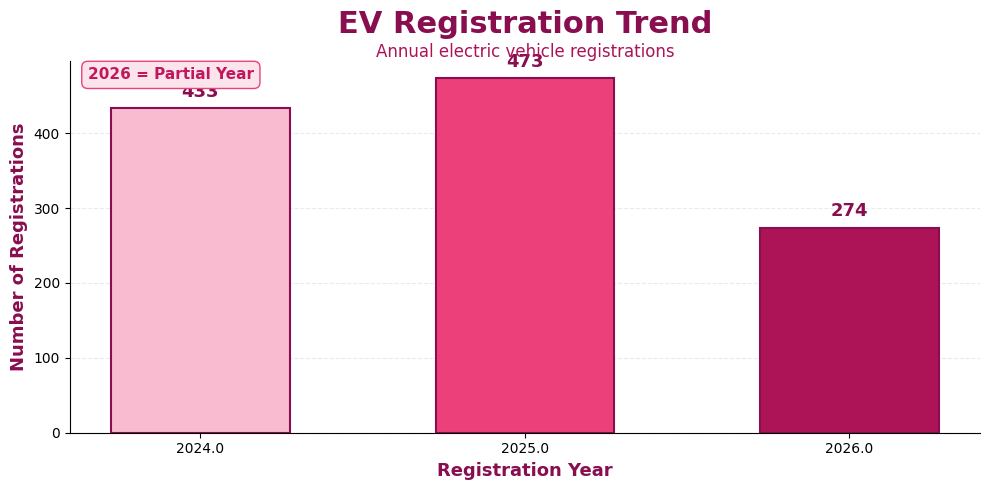

In [165]:
import matplotlib.pyplot as plt
import numpy as np

# Yearly registrations
yearly_reg = df['Registration_Year'].value_counts().sort_index()

years = yearly_reg.index.astype(str)
values = yearly_reg.values

# Pink shades
pink_colors = ['#F8BBD0', '#EC407A', '#AD1457']

plt.figure(figsize=(10, 5))
ax = plt.gca()

# Bars
bars = ax.bar(
    years,
    values,
    width=0.55,
    color=pink_colors[:len(values)],
    edgecolor='#880E4F',
    linewidth=1.5
)

# Value labels + text
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max(values) * 0.02,
        f'{value:,}',
        ha='center',
        va='bottom',
        fontsize=13,
        fontweight='bold',
        color='#880E4F'
    )

# Title
plt.title(
    'EV Registration Trend',
    fontsize=22,
    fontweight='bold',
    color='#880E4F',
    pad=20
)

# Subtitle
plt.text(
    0.5, 1.01,
    'Annual electric vehicle registrations',
    transform=ax.transAxes,
    ha='center',
    fontsize=12,
    color='#AD1457'
)

# Axis labels
plt.xlabel(
    'Registration Year',
    fontsize=13,
    fontweight='bold',
    color='#880E4F'
)

plt.ylabel(
    'Number of Registrations',
    fontsize=13,
    fontweight='bold',
    color='#880E4F'
)

# Add annotation
plt.text(
    0.02, 0.95,
    '2026 = Partial Year',
    transform=ax.transAxes,
    fontsize=11,
    fontweight='bold',
    color='#C2185B',
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='#FCE4EC',
        edgecolor='#EC407A'
    )
)

# Grid
ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.25
)

ax.set_axisbelow(True)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

I analyzed EV registration trends by extracting the registration year from the date column and aggregating the number of vehicles registered in each year. I used a line chart because the year represents a time sequence. I also considered that 2026 is a partial year in this dataset.

# 2 Which EV manufacturer has the highest market share?

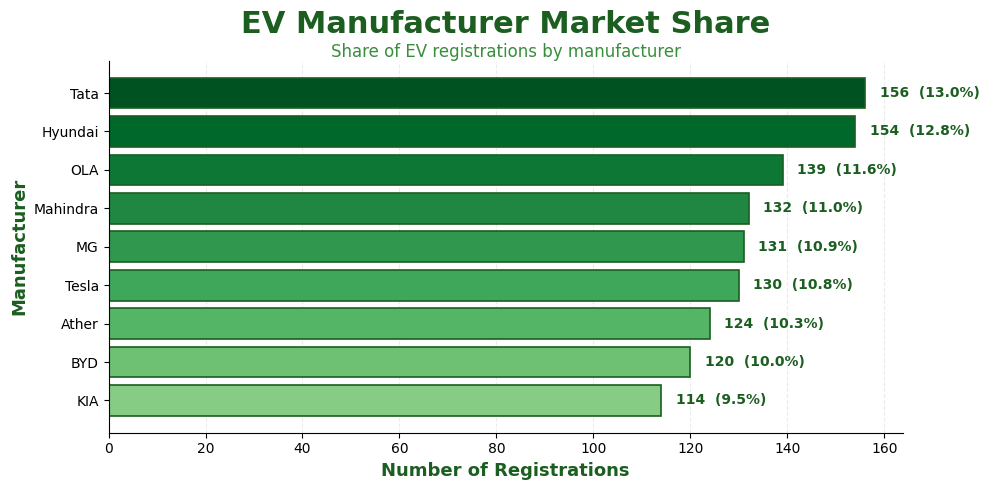

In [164]:
import matplotlib.pyplot as plt
import numpy as np

# Count registrations by manufacturer
manufacturer_count = (
    df['Manufacturer']
    .value_counts()
    .sort_values(ascending=True)
)

# Calculate market share
total = manufacturer_count.sum()
market_share = (manufacturer_count / total) * 100

plt.figure(figsize=(10, 5))
ax = plt.gca()

# Green gradient
colors = plt.cm.Greens(
    np.linspace(0.45, 0.95, len(manufacturer_count))
)

bars = ax.barh(
    manufacturer_count.index,
    manufacturer_count.values,
    color=colors,
    edgecolor='#1B5E20',
    linewidth=1.2
)

# Add count + percentage
for bar, count, share in zip(
    bars,
    manufacturer_count.values,
    market_share.values
):
    ax.text(
        bar.get_width() + 3,
        bar.get_y() + bar.get_height() / 2,
        f'{count:,}  ({share:.1f}%)',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='#1B5E20'
    )

# Title
plt.title(
    'EV Manufacturer Market Share',
    fontsize=22,
    fontweight='bold',
    color='#1B5E20',
    pad=20
)

# Subtitle
plt.text(
    0.5,
    1.01,
    'Share of EV registrations by manufacturer',
    transform=ax.transAxes,
    ha='center',
    fontsize=12,
    color='#388E3C'
)

# Axis labels
plt.xlabel(
    'Number of Registrations',
    fontsize=13,
    fontweight='bold',
    color='#1B5E20'
)

plt.ylabel(
    'Manufacturer',
    fontsize=13,
    fontweight='bold',
    color='#1B5E20'
)

# Grid
ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.25
)

ax.set_axisbelow(True)

# Remove unnecessary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

I calculated manufacturer-level registration counts and divided each manufacturer's registrations by the total registrations to obtain market share. I used a horizontal bar chart because it makes comparison between multiple manufacturers easier

# 3 Which EV model is most popular?

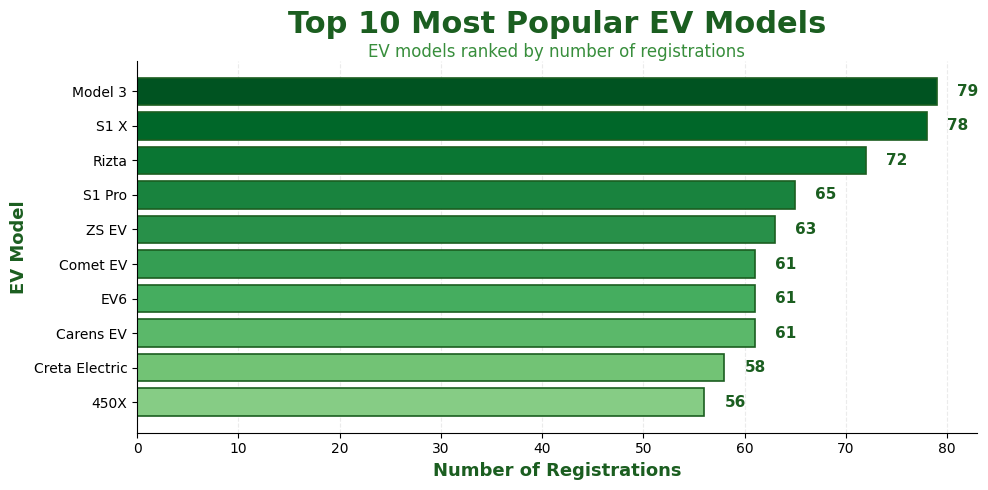

In [166]:
import matplotlib.pyplot as plt
import numpy as np

# Count registrations by model
model_count = (
    df['Model']
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 5))
ax = plt.gca()

# Green gradient
colors = plt.cm.Greens(
    np.linspace(0.45, 0.95, len(model_count))
)

bars = ax.barh(
    model_count.index,
    model_count.values,
    color=colors,
    edgecolor='#1B5E20',
    linewidth=1.2
)

# Add values
for bar, value in zip(bars, model_count.values):
    ax.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height() / 2,
        f'{value:,}',
        va='center',
        fontsize=11,
        fontweight='bold',
        color='#1B5E20'
    )

# Title
plt.title(
    'Top 10 Most Popular EV Models',
    fontsize=22,
    fontweight='bold',
    color='#1B5E20',
    pad=20
)

# Subtitle
plt.text(
    0.5,
    1.01,
    'EV models ranked by number of registrations',
    transform=ax.transAxes,
    ha='center',
    fontsize=12,
    color='#388E3C'
)

plt.xlabel(
    'Number of Registrations',
    fontsize=13,
    fontweight='bold',
    color='#1B5E20'
)

plt.ylabel(
    'EV Model',
    fontsize=13,
    fontweight='bold',
    color='#1B5E20'
)

# Grid
ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.25
)

ax.set_axisbelow(True)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

I used value_counts() on the Model column to calculate registration frequency and selected the top 10 models. I used a horizontal bar chart because it makes model names and their relative registration volumes easy to compare.

1 How are EV registrations changing over time? 2 Which EV manufacturer has the highest market share? 3 Which EV model is most popular? 4 Which state has the highest EV adoption? 5 Which vehicle category is growing fastest? 6 What is the average EV price by manufacturer? 7 How does battery range vary by manufacturer? 8 Is vehicle price related to battery range? 9 Which states show the strongest EV growth? 10 What factors appear to influence EV adoption?

In [100]:
df.columns

Index(['Record_ID', 'Registration_Date', 'Manufacturer', 'Model',
       'Vehicle_Category', 'City', 'State', 'Price_INR', 'Battery_Range_KM',
       'Units_Sold', 'Charging_Type', 'Area_Type'],
      dtype='object')